# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **⚠️ これはベータ版です**

前提知識としてCLIPについての知識が必要です。

現在、Chapter31はベータ版です。解説やTODO問題はありません。

また、モデルの性能評価もまだ行なっていません。

コードの解読やモデルの性能評価はご自身で行なっていただくようお願いします。

早期公開は、小出しにしながら積極的にアピールしていくというプロジェクトの広報方針転換によるものです。

そのため、急いで取り組む必要はありません。

徐々に解説などを追加して充実させていきますので、そのタイミングで取り組んでいただければと思います。

# **Chapter 31: Vision Instruction Tuning**

このChapterでは、Vision Pretraining済みモデルを、画像を見ながら質問に答えるVision Instruction Tuningへ拡張します。<br>
ポイントは、Vision Pretraining用コードをほとんどそのまま使えることです。<br>

|  | データ | モデル出力 |
|---|---|---|
| Pretraining | Webデータ | ブログ形式 |
| Instruction Tuning | 対話データ | 対話形式 |
| Vision Instruction Tuning | 画像 + 質問 + 回答 | 画像を見た質問応答 |

大事なのは、「画像を入れる場所」と「lossを計算する場所」を分けて考えることです。<br>
画像部分とユーザー質問部分は `-100` でlossを無視し、AI回答部分だけを学習します。

## **Section 1: 事前学習モデルの読み込み**

今回もG4 GPUを使います。最低で30クレジットは欲しいです。<br>
全くクレジットがない、、、！という方は、追加で100クレジットを購入してください、、、😭

**`Check Point`** <label><input type="checkbox">G4 GPUに接続したことを確認した<label>

モデルクラスは前回と同じです。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)


class RelativePositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 相対位置バイアスの辞書の要素数を計算する
        # 相対位置は -(T-1) から +(T-1) までとりうるので、要素数は 2*T-1
        self.relative_position_count = 2 * config.input_sequence_length - 1
        self.bias_embedding_table = nn.Embedding(self.relative_position_count, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions

        # 相対位置indexを非負の値にシフトする(埋め込みテーブル参照用)
        relative_position_indices = relative_position_matrix + key_len - 1

        # 相対位置indexに対応するbias embeddingを取得する
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(relative_position_indices)

        # 不要な次元を削除する
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix

class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(config=config)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        return projected

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, config.vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


In [ ]:
def generate_stream(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -model.config.input_sequence_length:]
            logits, _ = model(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] / temperature

            if top_k is not None:
                values, _ = torch.topk(last_logits, min(top_k, last_logits.size(-1)))
                last_logits = last_logits.masked_fill(last_logits < values[:, [-1]], float('-inf'))

            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(last_logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                last_logits = last_logits.masked_fill(indices_to_remove, float('-inf'))

            probs = F.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_indices = torch.cat((input_indices, next_token), dim=1)
            yield input_indices


def generate(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    generated_indices = input_indices
    for generated_indices in generate_stream(
        model,
        input_indices,
        max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    ):
        pass
    return generated_indices

class EveryonesGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = config.vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(config=config)
        # targetが-100の場所は、lossを計算しない
        self.criterion = nn.CrossEntropyLoss(ignore_index=-100)

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する


In [ ]:
PAD_TOKEN_ID = 50256
IGNORE_INDEX = -100
NUM_IMAGE_PATCHES = 256
VISION_PROJECTOR_HIDDEN_DIM = 2048
VISION_ENCODER = "openai/clip-vit-large-patch14"

from transformers import CLIPVisionModel

class VLM(nn.Module):
    def __init__(self, llm):
        super().__init__()
        self.llm = llm

        # CLIP Vision Encoderは画像特徴抽出器として使う。
        self.vision = CLIPVisionModel.from_pretrained(VISION_ENCODER)

        # CLIPの画像特徴をLLMの埋め込み次元へ変換するProjector。
        self.projector = nn.Sequential(
            nn.Linear(self.vision.config.hidden_size, VISION_PROJECTOR_HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(VISION_PROJECTOR_HIDDEN_DIM, llm.config.embedding_dim),
        )

        self.loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    def make_multimodal_embeddings(self, image_batch, input_token_ids):
        text_embeddings = self.llm.token_embedding_layer.embed(input_token_ids)

        # CLIPのパラメータはOptimizer作成前に凍結する。
        vision_outputs = self.vision(image_batch, output_hidden_states=True)
        image_features = vision_outputs.hidden_states[-1][:, 1:]
        image_embeddings = self.projector(image_features)

        # 先頭NUM_IMAGE_PATCHES個のtoken埋め込みを画像埋め込みに置き換える。
        multimodal_embeddings = torch.cat(
            [image_embeddings, text_embeddings[:, NUM_IMAGE_PATCHES:]],
            dim=1,
        )
        return multimodal_embeddings

    def forward_logits(self, image_batch, input_token_ids):
        multimodal_embeddings = self.make_multimodal_embeddings(image_batch, input_token_ids)
        blocks_output = self.llm.blocks(multimodal_embeddings)
        logits = self.llm.vocab_projection(blocks_output)
        return logits

    def forward(self, image_batch, input_token_ids, target_labels):
        logits = self.forward_logits(image_batch, input_token_ids)

        batch_size, token_len, vocab_size = logits.shape
        loss = self.loss_fn(
            logits.view(batch_size * token_len, vocab_size),
            target_labels.view(batch_size * token_len),
        )

        return logits, loss

Configクラスについても、前回と同じです。

In [ ]:
class Config:
    vocab_size = 50257
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280
    hidden_dim: int = 5120
    num_attention_heads: int = 10
    layer_count: int = 20

    # === optimization ===
    max_learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"

In [ ]:
config = Config()

In [ ]:
vocab_size = 50257
# GPUにはまだ転送しない。
model = EveryonesGPT(config = config)

In [ ]:
model.eval()
vision_model = VLM(model)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bi

In [ ]:
# VLM全体をコンパイルして学習を高速化する
# ⚠️ このセルを2回以上実行しないでく
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_vision_model = torch.compile(vision_model)

HuggingFaceにログインします。

In [ ]:
from huggingface_hub import login
login()

Vision Pretraining済みモデルの重みだけをダウンロードします。

In [ ]:
from huggingface_hub import hf_hub_download

vision_pretrained_repo_id = # TODO: Chapter30で使用したリポジトリ
vision_pretrained_filename = # TODO: Vision Pretrainingのチェックポイント

hf_hub_download(
    repo_id=vision_pretrained_repo_id,
    filename=vision_pretrained_filename,
    repo_type="model",
    local_dir=".",
)

checkpoint_010000_vision_instruction.pt:   0%|          | 0.00/7.54G [00:00<?, ?B/s]

'checkpoint_010000_vision_instruction.pt'

In [ ]:
checkpoint_data = torch.load(vision_pretrained_filename, map_location="cpu")
model_state_dict = checkpoint_data["model_state_dict"]
print(type(model_state_dict))

<class 'collections.OrderedDict'>


In [ ]:
compiled_vision_model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [ ]:
compiled_vision_model.to(config.device_type)

OptimizedModule(
  (_orig_mod): VLM(
    (llm): EveryonesGPT(
      (token_embedding_layer): TokenEmbedding(
        (token_embedding_table): Embedding(50257, 1280)
      )
      (blocks): Sequential(
        (0): TransformerBlock(
          (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (multihead_attention): MultiHeadAttention(
            (attention_heads): ModuleList(
              (0-9): 10 x AttentionHead(
                (key_fc): Linear(in_features=1280, out_features=128, bias=False)
                (query_fc): Linear(in_features=1280, out_features=128, bias=False)
                (value_fc): Linear(in_features=1280, out_features=128, bias=False)
                (relative_position_embedding_layer): RelativePositionEmbedding(
                  (bias_embedding_table): Embedding(1024, 1)
                )
              )
            )
            (output_projection): Li

Vision Pretrained済みモデルの推論を確認してみましょう！

画像を入力し、テキストを生成させてみます。

In [ ]:
@torch.no_grad()
def vlm_generate(model, image_tensor, input_token_ids, max_new_tokens, temperature=1.0):
    model.eval()

    # 指定したトークン数max_new_tokensのみ生成する
    for _ in range(max_new_tokens):
        input_conditioned = input_token_ids[:, -model.llm.config.input_sequence_length:] # 入力を切り取る

        # 順伝播はlogitsを返す。
        logits = model.forward_logits(image_tensor, input_conditioned)
        last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
        last_logits = last_logits / temperature
        probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

        # 次のトークンをサンプリングする
        next_token = torch.multinomial(probs, num_samples=1)

        # 新しいトークンを統合し、input_token_idsを更新する。
        input_token_ids = torch.cat((input_token_ids, next_token), dim=1)

    # 最終的な`input_token_ids`を返す。長さは元の`input_token_ids`＋`max_new_tokens`
    return input_token_ids

In [ ]:
!wget -q https://raw.githubusercontent.com/HayatoHongo/nanoGPTVision/main/hodomoe_cat.png -O /content/hodomoe_cat.png

In [ ]:
from PIL import Image
from transformers import CLIPImageProcessor

image_processor = CLIPImageProcessor.from_pretrained(VISION_ENCODER)
image = Image.open("/content/hodomoe_cat.png").convert("RGB")
image_tensor = image_processor(images=image, return_tensors="pt")["pixel_values"].to(config.device_type)

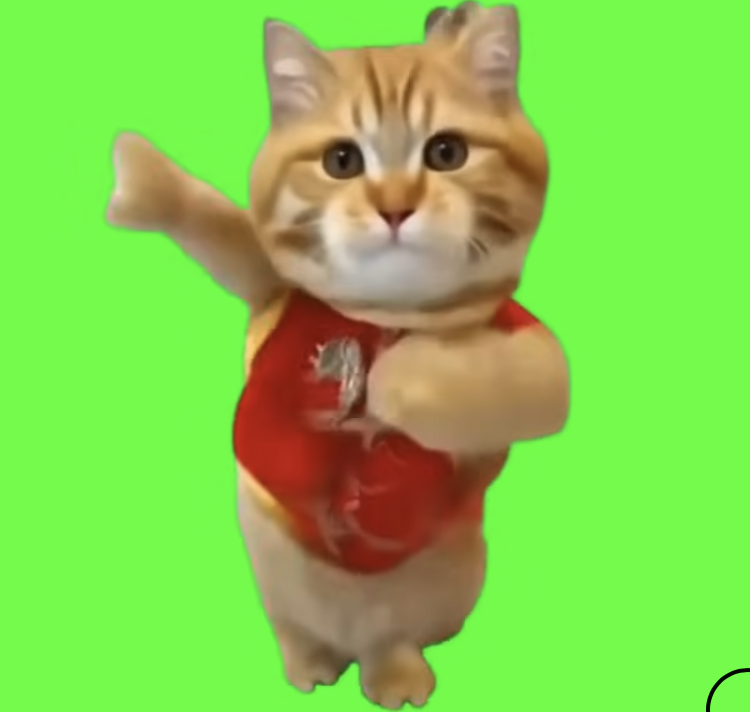

In [ ]:
image

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
prompt = "<USER>Why is this animal dancing?<AI>"
prompt_token_ids = tokenizer.encode(prompt, allowed_special="all")
input_token_ids = [PAD_TOKEN_ID] * NUM_IMAGE_PATCHES + prompt_token_ids
input_token_ids = torch.tensor(input_token_ids, dtype=torch.long, device=config.device_type).unsqueeze(0)

generated_token_ids = vlm_generate(compiled_vision_model, image_tensor, input_token_ids, max_new_tokens=64, temperature=0.3) # 温度は低め
generated_token_ids = generated_token_ids.squeeze(0).tolist()[input_token_ids.shape[1]:]
generated_text = tokenizer.decode(generated_token_ids)
print(generated_text)

This animal is dancing to create a fun and playful atmosphere. The image shows a cat standing on a green field, which might be a part of a themed event or a themed party. The act of the cat and the cat's movements create a fun and engaging environment for the audience. It is a common sight at events


**`Check Point`** <label><input type="checkbox">5回推論して、出力の傾向を確かめた。<label>

## **Section 2: Vision Instruction Tuningへ拡張**

やることはVision Pretrainingとほとんど同じです。

- 画像をtokenizerに追加しません。
- 画像用の新しいlossも作りません。
- CLIP Vision Encoderは凍結します。
- 画像をCLIPで256個の埋め込みにして、テキスト列の先頭へ差し込みます。
- `-100` のmaskを使って、画像部分とユーザー質問部分のlossを無視します。
- AI回答部分だけを学習します。

つまり、Vision Pretrainingとの差分はほぼ **データの中身** です。<br>
キャプションではなく、`画像 + ユーザー質問 + AI回答` を使います。

つまり、Vision Pretraining では画像の解説、すなわちキャプション生成に注力していました。

しかし、今回は画像に関する質問に対する回答を学ぶことによって、キャプション生成にとどまらず、画像を見ながら会話に答える、というタスクをこなすことを目的としています。

### **実は省略できること**

VLMという名前だけ聞くと、何か巨大な仕組みを追加したくなります。<br>
でもこの教材では、最初の一歩として以下は省略します。

- **画像専用tokenの追加**: PAD tokenを仮置きして、埋め込みだけ画像特徴に置き換えれば十分です。
- **CLIPの再学習**: 画像特徴はすでに強いので凍結します。
- **新しいTrainer**: バッチが `images, input_ids, labels` なら、Vision PretrainingのTrainerをそのまま使えます。
- **複雑な会話テンプレート**: まずは `<USER>{質問}<AI>{回答}` だけで十分です。
- **動的padding / collate_fn**: すべて固定長に前処理すれば不要です。

さらにVRAMがきつい場合は、LLMを凍結してProjectorだけ学習する形でも試せます。<br>

ProjectorとLLMを学習し、CLIPだけ凍結します。

In [ ]:
# Colabで初回のみ実行してください。
# CLIPVisionModel / CLIPImageProcessor と、画像ファイルの展開に使います。
!pip -q install transformers pillow zstandard
!apt-get -qq update
!apt-get -qq install -y zstd unzip wget

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


Vision用データセットを準備します。

chatは、すでに共通テンプレにそろえたJSONLを使います。

```json
{"image_file": "...", "user": "...", "assistant": "..."}
```

このNotebookではJSONLを読み、画像ファイル名と画像フォルダをつなげて `image_path` を作ります。<br>
その後の処理は、Vision PretrainingでもVision Instruction Tuningでも同じです。

In [ ]:
# LLaVA-Instruct-150Kの共通chat JSONLをダウンロードします。
!wget -q https://huggingface.co/datasets/HayatoHongo/LLaVA-Instruct-150K/resolve/main/vision_instruction_chat_unified.jsonl -O /content/vision_instruction_chat_unified.jsonl
!head -n 3 /content/vision_instruction_chat_unified.jsonl

{"image_file": "000000093030.jpg", "user": "Is it clear whether the woman is at a specific event or just at home?", "assistant": "It is not possible to definitively determine from the image whether the woman is at a specific event or at home. However, since she is pouring wine, it is likely that she is attending some kind of social gathering or event, or enjoying a relaxed moment at home."}
{"image_file": "000000151577.jpg", "user": "Is the image a close-up of the street sign on the pole?", "assistant": "Yes, the image is a close-up of the street sign on a pole."}
{"image_file": "000000062581.jpg", "user": "What is the setting of the image?", "assistant": "The setting of the image is a gravel lot, where a bus frame is sitting."}


展開をする思い処理があるので、およそ10分かかります。

In [ ]:
# COCO train2017画像をダウンロードして展開します。20分程度の時間がかかります。
# すでに /content/coco/train2017 がある場合、このセルはスキップしてOKです。
!mkdir -p /content/coco
!wget -c http://images.cocodataset.org/zips/train2017.zip -O /content/coco/train2017.zip
!unzip -qn /content/coco/train2017.zip -d /content/coco

--2026-06-04 22:29:20--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.223.117, 16.15.223.194, 16.15.191.169, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.223.117|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘/content/coco/train2017.zip’

/content/coco/train 100%[===================>]  18.01G  16.4MB/s    in 19m 25s 

2026-06-04 22:48:46 (15.8 MB/s) - ‘/content/coco/train2017.zip’ saved [19336861798/19336861798]



In [ ]:
import json
import os

unified_chat_file = open("/content/vision_instruction_chat_unified.jsonl", "r", encoding="utf-8")
training_text_file = open("/content/vision_instruction_pairs.jsonl", "w", encoding="utf-8")

sample_count = 0
for chat_json_line in unified_chat_file:
    chat_sample = json.loads(chat_json_line)

    training_text_sample = {
        "image_path": os.path.join("/content/coco/train2017", chat_sample["image_file"]),
        "prompt_text": "<USER>" + chat_sample["user"] + "<AI>",
        "response_text": chat_sample["assistant"] + "<|endoftext|>",
    }
    training_text_file.write(json.dumps(training_text_sample, ensure_ascii=False) + "\n")
    sample_count += 1

unified_chat_file.close()
training_text_file.close()

print("saved:", "/content/vision_instruction_pairs.jsonl")
print("samples:", sample_count)

saved: /content/vision_instruction_pairs.jsonl
samples: 361411


In [ ]:
text_pairs_file = open("/content/vision_instruction_pairs.jsonl", "r", encoding="utf-8")

print(text_pairs_file.readline().rstrip())
print(text_pairs_file.readline().rstrip())
print(text_pairs_file.readline().rstrip())

text_pairs_file.close()

{"image_path": "/content/coco/train2017/000000093030.jpg", "prompt_text": "<USER>Is it clear whether the woman is at a specific event or just at home?<AI>", "response_text": "It is not possible to definitively determine from the image whether the woman is at a specific event or at home. However, since she is pouring wine, it is likely that she is attending some kind of social gathering or event, or enjoying a relaxed moment at home.<|endoftext|>"}
{"image_path": "/content/coco/train2017/000000151577.jpg", "prompt_text": "<USER>Is the image a close-up of the street sign on the pole?<AI>", "response_text": "Yes, the image is a close-up of the street sign on a pole.<|endoftext|>"}
{"image_path": "/content/coco/train2017/000000062581.jpg", "prompt_text": "<USER>What is the setting of the image?<AI>", "response_text": "The setting of the image is a gravel lot, where a bus frame is sitting.<|endoftext|>"}


In [ ]:
import json
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
max_sequence_length = config.input_sequence_length

image_path_list = []
input_token_ids_list = []
target_labels_list = []

text_pairs_file = open("/content/vision_instruction_pairs.jsonl", "r", encoding="utf-8")

for text_pair_json_line in text_pairs_file:
    training_text_sample = json.loads(text_pair_json_line)

    image_path = training_text_sample["image_path"]
    prompt_text = training_text_sample["prompt_text"]
    response_text = training_text_sample["response_text"]

    prompt_token_ids = tokenizer.encode(prompt_text, allowed_special="all")
    response_token_ids = tokenizer.encode(response_text, allowed_special={"<|endoftext|>"})

    image_placeholder_token_ids = [PAD_TOKEN_ID] * NUM_IMAGE_PATCHES
    full_token_ids = image_placeholder_token_ids + prompt_token_ids + response_token_ids
    full_target_labels = [IGNORE_INDEX] * NUM_IMAGE_PATCHES + [IGNORE_INDEX] * len(prompt_token_ids) + response_token_ids

    # shiftするので、full_token_idsはinput_sequence_length + 1まで持っておく。
    full_token_ids = full_token_ids[:max_sequence_length + 1]
    full_target_labels = full_target_labels[:max_sequence_length + 1]

    input_token_ids = full_token_ids[:-1]
    target_labels = full_target_labels[1:]

    padding_token_count = max_sequence_length - len(input_token_ids)
    input_token_ids = input_token_ids + [PAD_TOKEN_ID] * padding_token_count
    target_labels = target_labels + [IGNORE_INDEX] * padding_token_count

    image_path_list.append(image_path)
    input_token_ids_list.append(input_token_ids)
    target_labels_list.append(target_labels)

text_pairs_file.close()

input_token_ids_tensor = torch.tensor(input_token_ids_list, dtype=torch.int32)
target_labels_tensor = torch.tensor(target_labels_list, dtype=torch.int32)

image_paths_file = open("/content/vision_instruction_image_paths.json", "w", encoding="utf-8")
json.dump(image_path_list, image_paths_file, ensure_ascii=False)
image_paths_file.close()

torch.save(input_token_ids_tensor, "/content/vision_instruction_input_ids.pt")
torch.save(target_labels_tensor, "/content/vision_instruction_labels.pt")

print("images:", len(image_path_list))
print("input_ids:", input_token_ids_tensor.shape)
print("labels:", target_labels_tensor.shape)

images: 361411
input_ids: (361411, 1024)
labels: (361411, 1024)


Vision用DataLoaderを定義します。

前処理が終わっているので、DataLoaderの仕事はかなり少なくなります。

- ランダムに行番号を選ぶ
- 画像を開く
- `input_ids` と `labels` を取り出す
- tensorにしてGPUへ送る

会話のparse、tokenize、mask作成、paddingはもう行いません。

In [ ]:
from PIL import Image
from transformers import CLIPImageProcessor

class VisionDataLoader:
    def __init__(self, image_paths_file_path, input_ids_file_path, labels_file_path, config):
        self.config = config
        self.image_processor = CLIPImageProcessor.from_pretrained(VISION_ENCODER)

        image_paths_file = open(image_paths_file_path, "r", encoding="utf-8")
        self.image_paths = json.load(image_paths_file)
        image_paths_file.close()

        self.input_token_ids = torch.load(input_ids_file_path, map_location="cpu", mmap=True)
        self.target_labels = torch.load(labels_file_path, map_location="cpu", mmap=True)

    def get_batch(self):
        sample_count = len(self.image_paths)
        sample_indices = torch.randint(sample_count, (self.config.batch_size,))

        pil_images = []
        for sample_index in sample_indices.tolist():
            pil_image = Image.open(self.image_paths[sample_index]).convert("RGB")
            pil_images.append(pil_image)

        image_batch = self.image_processor(images=pil_images, return_tensors="pt")["pixel_values"]
        input_token_ids = self.input_token_ids[sample_indices].long()
        target_labels = self.target_labels[sample_indices].long()
        return image_batch.to(self.config.device_type), input_token_ids.to(self.config.device_type), target_labels.to(self.config.device_type)

vision_data_loader = VisionDataLoader(
    image_paths_file_path="/content/vision_instruction_image_paths.json",
    input_ids_file_path="/content/vision_instruction_input_ids.pt",
    labels_file_path="/content/vision_instruction_labels.pt",
    config=config,
)

In [ ]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_steps = config.total_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


Vision用Trainerを定義します。

普通のTrainerとの違いは、バッチが `images, input_ids, labels` の3つになることだけです。<br>
Vision PretrainingとVision Instruction Tuningで同じTrainerを使います。

In [ ]:
import time
import os
from huggingface_hub import create_repo
from huggingface_hub import upload_file

class VisionTrainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, checkpoint_name, repo_id):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir
        self.checkpoint_name = checkpoint_name
        self.repo_id = repo_id

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        image_batch, input_token_ids, target_labels = self.data_loader.get_batch()
        self.optimizer.zero_grad()
        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):
          logits, loss = self.model(image_batch, input_token_ids, target_labels)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def save_checkpoint(self, step):
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        checkpoint_path = os.path.join(
            self.checkpoint_dir,
            f"checkpoint_{step:06d}_{self.checkpoint_name}.pt",
        )
        checkpoint_data = {
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "config": config_dict,
            "current_step": step,
            "vision_encoder": VISION_ENCODER,
            "num_image_patches": NUM_IMAGE_PATCHES,
            "vision_projector_hidden_dim": VISION_PROJECTOR_HIDDEN_DIM,
        }
        torch.save(checkpoint_data, checkpoint_path)
        return checkpoint_path

    def train(self):
        total_train_time = 0
        last_log_time = time.time()

        for step in range(1, self.config.total_steps + 1):
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                checkpoint_path = self.save_checkpoint(step)
                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                upload_file(
                    repo_id=self.repo_id,
                    repo_type="model",
                    path_or_fileobj=checkpoint_path,
                    path_in_repo=os.path.basename(checkpoint_path),
                )

            current_log_time = time.time()
            interval_seconds = current_log_time - last_log_time
            total_train_time += interval_seconds

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval_seconds
            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second)} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s",
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

学習設定とOptimizerを作成します。

ここで初めて、どのパラメータを学習するかを決めます。<br>
Vision PretrainingではLLMを凍結し、Vision Instruction TuningではLLMも学習します。

In [ ]:
config.batch_size = 24
config.total_steps = 10_000
config.checkpoint_save_frequency = 5_000
config.max_learning_rate = 1e-5
config.min_learning_rate = 1e-6
config.warmup_steps = 500

config_dict = {
    "batch_size": config.batch_size,
    "total_steps": config.total_steps,
    "checkpoint_save_frequency": config.checkpoint_save_frequency,
    "input_sequence_length": config.input_sequence_length,
    "embedding_dim": config.embedding_dim,
    "hidden_dim": config.hidden_dim,
    "num_attention_heads": config.num_attention_heads,
    "layer_count": config.layer_count,
    "max_learning_rate": config.max_learning_rate,
    "min_learning_rate": config.min_learning_rate,
    "warmup_steps": config.warmup_steps,
    "device_type": config.device_type,
}

# CLIPは画像特徴抽出器として使うので、どちらの学習でも凍結する。
for parameter in vision_model.vision.parameters():
    parameter.requires_grad = False

# Projectorは、画像特徴をLLMの埋め込み空間へ写すために学習する。
for parameter in vision_model.projector.parameters():
    parameter.requires_grad = True

# Vision PretrainingではLLMを守る。Vision Instruction Tuningでは答え方も調整する。
for parameter in vision_model.llm.parameters():
    parameter.requires_grad = True

vision_optimizer = torch.optim.AdamW(
    compiled_vision_model.parameters(),
    lr=config.max_learning_rate,
    betas=(0.9, 0.95),
    weight_decay=0.0,
    fused=True,
)

In [ ]:
model_repo_id = "HayatoHongo/EveryonesGPT-VisionInstruction-checkpoints"

In [ ]:
compiled_vision_model.train()
compiled_vision_model.vision.eval()
compiled_vision_model.llm.train(mode=True)

vision_trainer = VisionTrainer(
    model=compiled_vision_model,
    optimizer=vision_optimizer,
    data_loader=vision_data_loader,
    config=config,
    checkpoint_name="vision_instruction",
    checkpoint_dir="./checkpoints-vision-instruction",
    repo_id=model_repo_id,
)

In [ ]:
vision_trainer.train()

step 00001 |  lr 2.000000e-08 |  train loss 3.5066 |  tok/s 84 |  tokens 24,576 |  time 291.71s
step 00002 |  lr 4.000000e-08 |  train loss 3.3364 |  tok/s 26614 |  tokens 49,152 |  time 292.63s
step 00003 |  lr 6.000000e-08 |  train loss 3.1361 |  tok/s 26732 |  tokens 73,728 |  time 293.55s
step 00004 |  lr 8.000000e-08 |  train loss 3.0914 |  tok/s 26631 |  tokens 98,304 |  time 294.48s
step 00005 |  lr 1.000000e-07 |  train loss 3.0699 |  tok/s 26721 |  tokens 122,880 |  time 295.40s
step 00006 |  lr 1.200000e-07 |  train loss 3.2882 |  tok/s 26921 |  tokens 147,456 |  time 296.31s
step 00007 |  lr 1.400000e-07 |  train loss 3.2399 |  tok/s 26848 |  tokens 172,032 |  time 297.22s
step 00008 |  lr 1.600000e-07 |  train loss 3.2355 |  tok/s 26637 |  tokens 196,608 |  time 298.15s
step 00009 |  lr 1.800000e-07 |  train loss 3.5108 |  tok/s 26774 |  tokens 221,184 |  time 299.06s
step 00010 |  lr 2.000000e-07 |  train loss 3.1003 |  tok/s 26905 |  tokens 245,760 |  time 299.98s
step 00

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...000_vision_instruction.pt:   0%|          |  558kB / 7.54GB            

step 05000 |  lr 5.736842e-06 |  train loss 1.8579 |  tok/s 177 |  tokens 122,880,000 |  time 5058.52s
step 05001 |  lr 5.735895e-06 |  train loss 1.9506 |  tok/s 26101 |  tokens 122,904,576 |  time 5059.46s
step 05002 |  lr 5.734947e-06 |  train loss 2.0673 |  tok/s 26960 |  tokens 122,929,152 |  time 5060.37s
step 05003 |  lr 5.734000e-06 |  train loss 1.8303 |  tok/s 26852 |  tokens 122,953,728 |  time 5061.29s
step 05004 |  lr 5.733053e-06 |  train loss 1.8473 |  tok/s 26669 |  tokens 122,978,304 |  time 5062.21s
step 05005 |  lr 5.732105e-06 |  train loss 1.9410 |  tok/s 26882 |  tokens 123,002,880 |  time 5063.12s
step 05006 |  lr 5.731158e-06 |  train loss 2.0612 |  tok/s 27225 |  tokens 123,027,456 |  time 5064.02s
step 05007 |  lr 5.730211e-06 |  train loss 1.8405 |  tok/s 26749 |  tokens 123,052,032 |  time 5064.94s
step 05008 |  lr 5.729263e-06 |  train loss 1.7375 |  tok/s 26820 |  tokens 123,076,608 |  time 5065.86s
step 05009 |  lr 5.728316e-06 |  train loss 1.9009 |  tok

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...000_vision_instruction.pt:   0%|          |  844kB / 7.54GB            

step 10000 |  lr 1.000000e-06 |  train loss 1.8648 |  tok/s 216 |  tokens 245,760,000 |  time 9801.73s


Visionモデルを保存します。<br>
ここではVLM全体の`state_dict`を保存します。推論時は、同じVLMクラスを作ってこの重みを読み込みます。

In [ ]:
torch.save(
    {
        "model_state_dict": compiled_vision_model.state_dict(),
        "config": config_dict,
        "vision_encoder": VISION_ENCODER,
        "num_image_patches": NUM_IMAGE_PATCHES,
        "vision_projector_hidden_dim": VISION_PROJECTOR_HIDDEN_DIM,
    },
    "vision_instruction_tuned_model.pt",
)

NameError: name 'compiled_vision_model' is not defined

In [ ]:
upload_file(
    repo_id=model_repo_id,
    repo_type="model",
    path_or_fileobj="vision_instruction_tuned_model.pt",
    path_in_repo="vision_instruction_tuned_model.pt",
)

学習曲線を観察しましょう。

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(vision_trainer.steps, vision_trainer.train_losses, label="Vision Instruction Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Vision Instruction Loss over Steps")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'vision_trainer' is not defined

<Figure size 800x500 with 0 Axes>

### **Visionモデルで推論**

最後に、画像つき推論を確認します。<br>
ここでは理解を優先して、KV cacheなしの素朴な生成にします。

In [ ]:
!wget -q https://raw.githubusercontent.com/HayatoHongo/nanoGPTVision/main/hodomoe_cat.png -O /content/hodomoe_cat.png

In [ ]:
from PIL import Image
from transformers import CLIPImageProcessor

image_processor = CLIPImageProcessor.from_pretrained(VISION_ENCODER)
image = Image.open("/content/hodomoe_cat.png").convert("RGB")
image_tensor = image_processor(images=image, return_tensors="pt")["pixel_values"].to(config.device_type)

In [ ]:
@torch.no_grad()
def vlm_generate(model, image_tensor, input_token_ids, max_new_tokens, temperature=1.0):
    model.eval()

    # 指定したトークン数max_new_tokensのみ生成する
    for _ in range(max_new_tokens):
        input_conditioned = input_token_ids[:, -model.llm.config.input_sequence_length:] # 入力を切り取る

        # 順伝播はlogitsを返す。
        logits = model.forward_logits(image_tensor, input_conditioned)
        last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
        last_logits = last_logits / temperature
        probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

        # 次のトークンをサンプリングする
        next_token = torch.multinomial(probs, num_samples=1)

        # 新しいトークンを統合し、input_token_idsを更新する。
        input_token_ids = torch.cat((input_token_ids, next_token), dim=1)

    # 最終的な`input_token_ids`を返す。長さは元の`input_token_ids`＋`max_new_tokens`
    return input_token_ids

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
prompt = "<USER>What is this animal doing?<AI>"
prompt_token_ids = tokenizer.encode(prompt, allowed_special="all")
input_token_ids = [PAD_TOKEN_ID] * NUM_IMAGE_PATCHES + prompt_token_ids
input_token_ids = torch.tensor(input_token_ids, dtype=torch.long, device=config.device_type).unsqueeze(0)

generated_token_ids = vlm_generate(compiled_vision_model, image_tensor, input_token_ids, max_new_tokens=128, temperature=0.5)
generated_token_ids = generated_token_ids.squeeze(0).tolist()[input_token_ids.shape[1]:]
generated_text = tokenizer.decode(generated_token_ids)
print(generated_text)

NameError: name 'compiled_vision_model' is not defined

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 31: Vision Instruction Tuning** <label><input type="checkbox"> Mark as Done</label>

In [ ]:
import gc
import torch

# 不要になった大きなオブジェクトを削除
if 'vision_model' in globals():
    del vision_model
if 'vision_trainer' in globals():
    del vision_trainer
if 'vision_optimizer' in globals():
    del vision_optimizer
if 'compiled_model' in globals():
    del compiled_model
if 'compiled_vision_model' in globals():
    del compiled_vision_model
if 'model' in globals():
    del model
if 'image_tensor' in globals():
    del image_tensor

# ガベージコレクションを実行し、GPUのキャッシュを解放
gc.collect()
torch.cuda.empty_cache()

print("GPUメモリを解放しました。")

GPUメモリを解放しました。
